In [1]:
import cfe
import scanpy as sc

cfe.settings.backend = "conda"
cfe.logger.setLevel("DEBUG")

[07/16/2025 05:37:43] INFO                                                                                                                                                                              
                                  _____     _ _ ______    _       ______            _                                                                                                                   
                                 / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                  
                                | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __                                                                                               
                                | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__|                                                                                          

数据

In [2]:
cluster_key = "clusters"
fadata = cfe.data.read_pancrease(n_obs=500 ,save_cluster_key=cluster_key)
fadata

[07/16/2025 05:37:44] DEBUG    sample 1 cells for every cluster                                                                                                                                         
                      DEBUG    sample random cells                                                                                                                                                      
                      DEBUG    Create a FateAnnData object from an existing AnnData object.                                                                                                             
                      DEBUG    FateAnnData add_trajectory                                                                                                                                               


AnnData object with n_obs × n_vars = 500 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    uns: 'cfe'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'count'

[07/16/2025 05:37:45] DEBUG    plot_trajectory                                                                                                                                                          
[07/16/2025 05:37:46] DEBUG    add waypoints                                                                                                                                                            
                      DEBUG    FateAnnData add_waypoints                                                                                                                                                
                      DEBUG    add waypoints shape is (210, 500), finished!                                                                                                                             


<Axes: title={'center': 'milestone_color'}, xlabel='UMAP1', ylabel='UMAP2'>

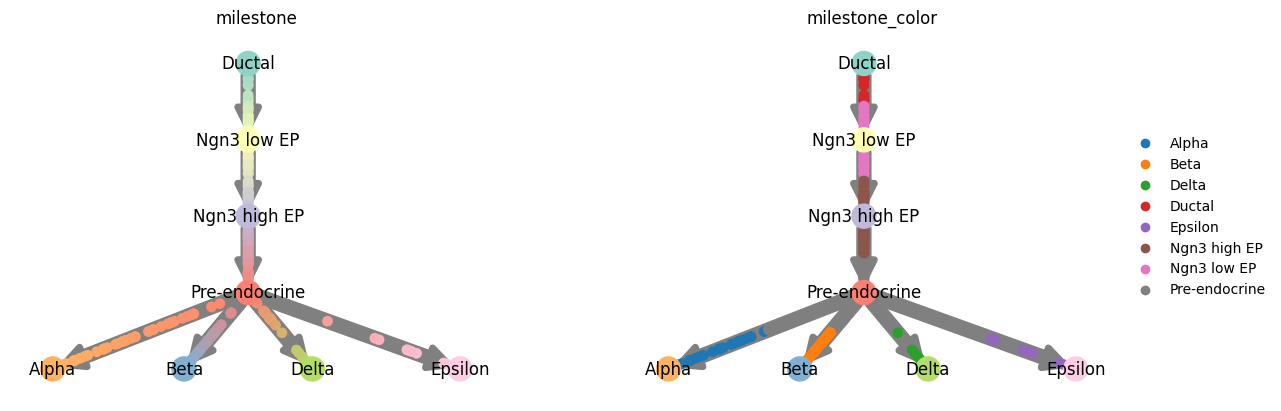

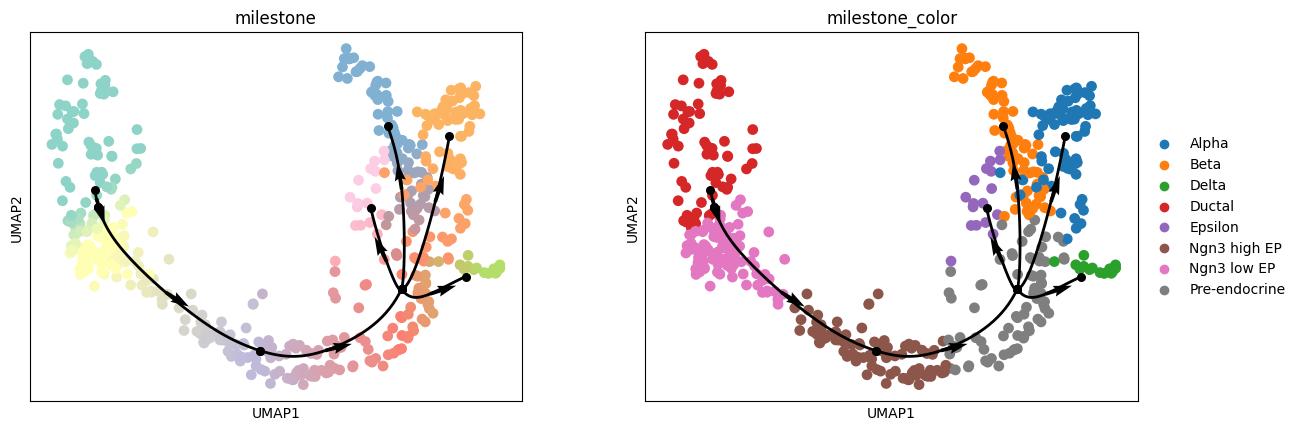

In [3]:
cluster_key = "milestone_color"
fadata.group_onto_nearest_milestones(cluster_key=cluster_key) # new cluster color

basis = "umap"
cluster_key_list = ["milestone", cluster_key]
cfe.plot.plot_graph(fadata, color=cluster_key_list)
cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)

In [ ]:
prior_information = {
    "cluster_key":"clusters"
}
fadata.add_prior_information(**prior_information)  # add prior information to fadata
parameters = {
    "epoch": 5,
}

method_name_list = ["velovi"]

for method_name in method_name_list:
    method = cfe.method.FateMethod(method_name=method_name)
    method.infer_trajectory(fadata, parameters=parameters)

[07/16/2025 05:37:49] DEBUG    CondaBackend __init__                                                                                                                                                    
                      INFO     method_backend: <cfe.method.fate_conda_backend.CondaBackend object at 0x7322e3d10700>                                                                                    
                      DEBUG    Temp wd: /tmp/tmpo1szg_2h                                                                                                                                                
                      DEBUG    transfer milestone color from tuple to list                                                                                                                              
                      DEBUG    transfer trajectory history: 'ref' to dict                                                                                                                           

[07/16/2025 05:43:02] INFO     find wrapper type: velocity                                                                                                                                              


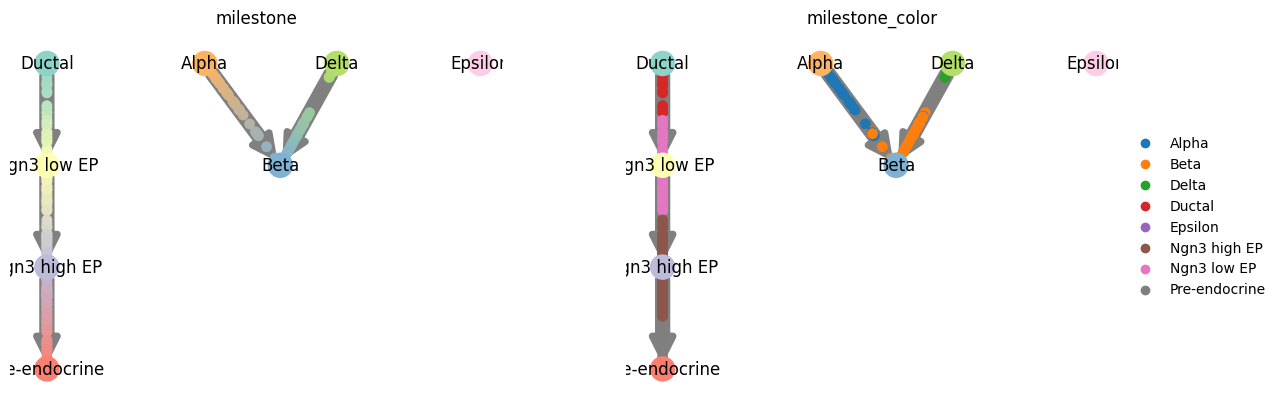

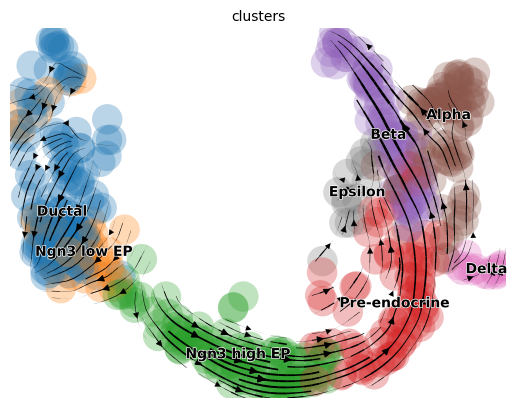

In [ ]:
# TODO: _calculate_geodesic_distances function crash on unconnected milestone network
# cfe.plot.plot_trajectory(fadata, basis=basis, color="clusters")
cfe.plot.plot_graph(fadata, color=cluster_key_list)
cfe.plot.plot_wrapper(fadata)